In [1]:
from PINN_XWave_DDP import *

/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:283: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:287: SyntaxWarning: invalid escape sequence '\p'
  if f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$' in title:
/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:290: SyntaxWarning: invalid escape sequence '\d'
  if f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$' in title:
/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:309: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')


In [ ]:
#Global variables physics constants
vth = .1
omega_ce = 2.
omega = 2.5
omega_pe = 1.0
phi_amp = 1.


k, k_lambda_D = dispersion(omega, omega_ce, omega_pe, vth)
print(f"k = {k:.3f}, k*lambda_D = {k_lambda_D:.3f}")

omega_list = [omega]
phi_amp_list = [phi_amp]  # Amplitude of the electric field
delta_list = [0.0]  # Phase factor for the wave solution

lamda = 2 * np.pi / k  # Wavelength
T = (2 * np.pi) / omega  # Period of the wave
xmin, xmax = 0, 3*lamda
tmin, tmax = 0, 3*T

L = xmax - xmin  # Length of the domain
tau = tmax - tmin  # Time duration of the wave
Nt = 2000 # Number of time points
Nx = 2000 # Number of spatial points
Nt_coll = 200 
Nx_coll = 200
dt = T/float(Nt)
dx = L/float(Nx)

t_arr = np.linspace(tmin, tmax, Nt)
x_arr = np.linspace(xmin, xmax, Nx)

print(f"k = {k:.4e}")
print(f"k lambda_debye = {k_lambda_D:.4e}")
print(f"L = {L:.3e} [c / omega_pe]")
print(f"T = {T:.3e} [1 / omega_pe]")
print(f"dx = {dx:.3e} [c / omega_pe]")
print(f"dt = {dt:.3e} [1 / omega_pe]")

X_arr, T_arr, phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat, = generate_data(xmin = xmin, xmax = xmax, tmin = tmin, tmax = tmax, nx = Nx, nt = Nt, vth=vth,
                                                                                                omega_ce = omega_ce, omega_pe = omega_pe, omega_list = omega_list, phi_amp_list=phi_amp_list,
                                                                                                delta_list=delta_list)

x_sparse, t_sparse, phi_sparse, Bdot_sparse = sparse_measurements(X_arr, T_arr, phi_flat, Bdot_flat, num_samples=500)

x_coll, t_coll, dx, dt = collocation_points(xmin, xmax, tmin, tmax, Nx_coll, Nt_coll, L, tau)

k = 1.432, k*lambda_D = 0.143
k = 1.4318e+00
k lambda_debye = 1.4318e-01
L = 1.317e+01 [c / omega_pe]
T = 2.513e+00 [1 / omega_pe]
dx = 6.583e-03 [c / omega_pe]
dt = 1.257e-03 [1 / omega_pe]


<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1954215/2645875149.py:5: SyntaxWarning: invalid escape sequence '\p'
  titles_GT = [f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$',
/tmp/ipykernel_1954215/2645875149.py:6: SyntaxWarning: invalid escape sequence '\d'
  f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$',


-------Plotting Ground Truth Values-------------


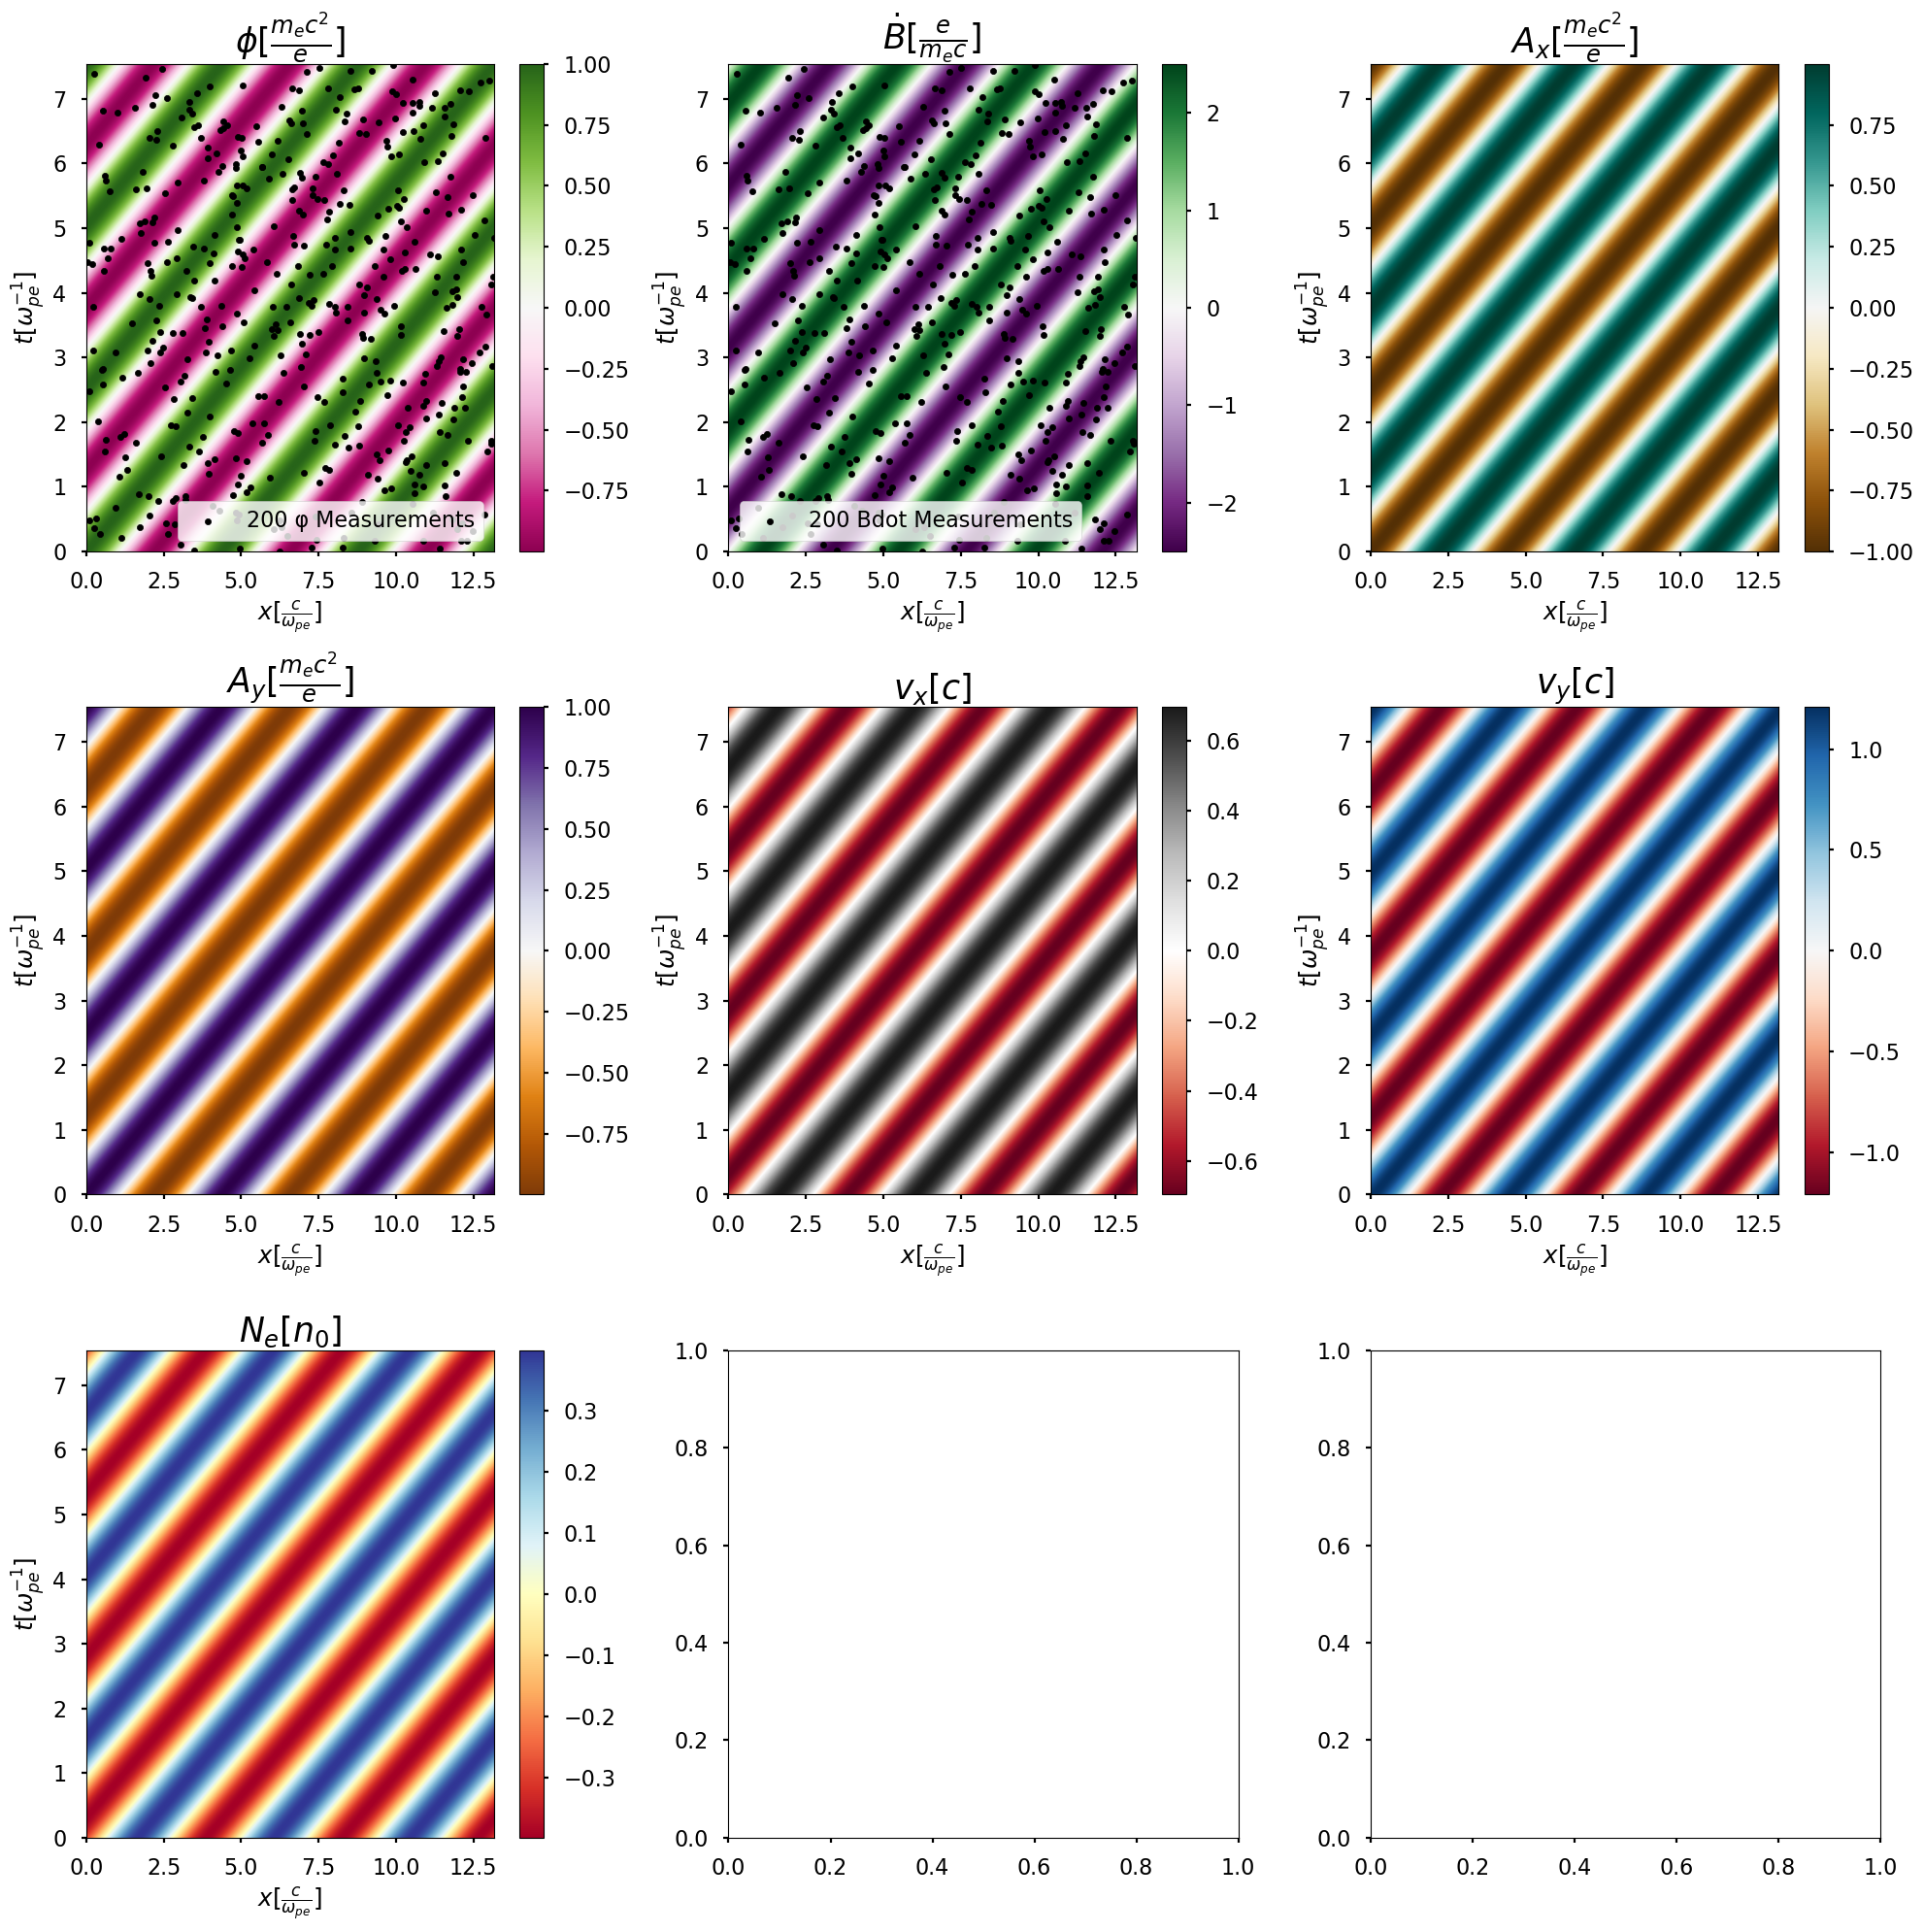

<Figure size 1280x880 with 0 Axes>

In [3]:
quantities_flat = [phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat]
extent_GT = [xmin, xmax, tmin, tmax]
quantities_GT = [x.reshape(Nt, Nx) for x in quantities_flat]
sparse = [x_sparse, t_sparse, phi_sparse, Bdot_sparse]
titles_GT = [f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$', 
            f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$',
            f'$A_x [\\frac{{m_{{e}}c^2}}{{e}}]$',
            f'$A_y [\\frac{{m_{{e}}c^2}}{{e}}]$',
            f'$v_x [c]$', 
            f'$v_y [c]$', 
            f'$N_e [n_0]$']

#Plot Ground Truth Values
print("-------Plotting Ground Truth Values-------------")
plot_analytical(quantities=quantities_GT, sparse = sparse, titles = titles_GT, extent = extent_GT)

TypeError: Image data of dtype complex128 cannot be converted to float

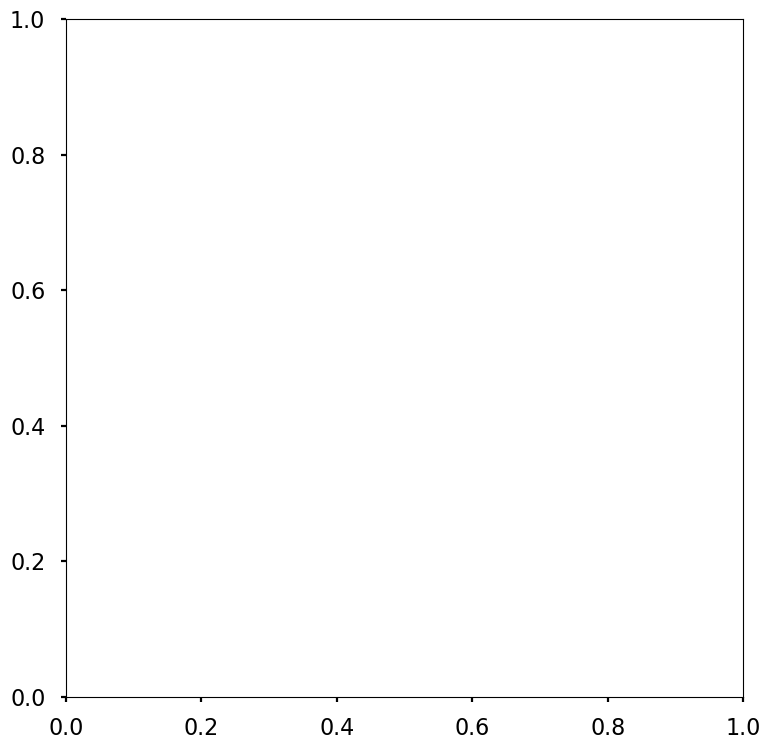

In [7]:
def compare_derivs(f,f_prime, dx):
    f_x = derivative_x(f, dx)
    plt.imshow(f_prime - f, extent = extent_GT, origin='lower', )
    return
phi = quantities_GT[0]
compare_derivs(phi, -1j*omega*phi, dx)

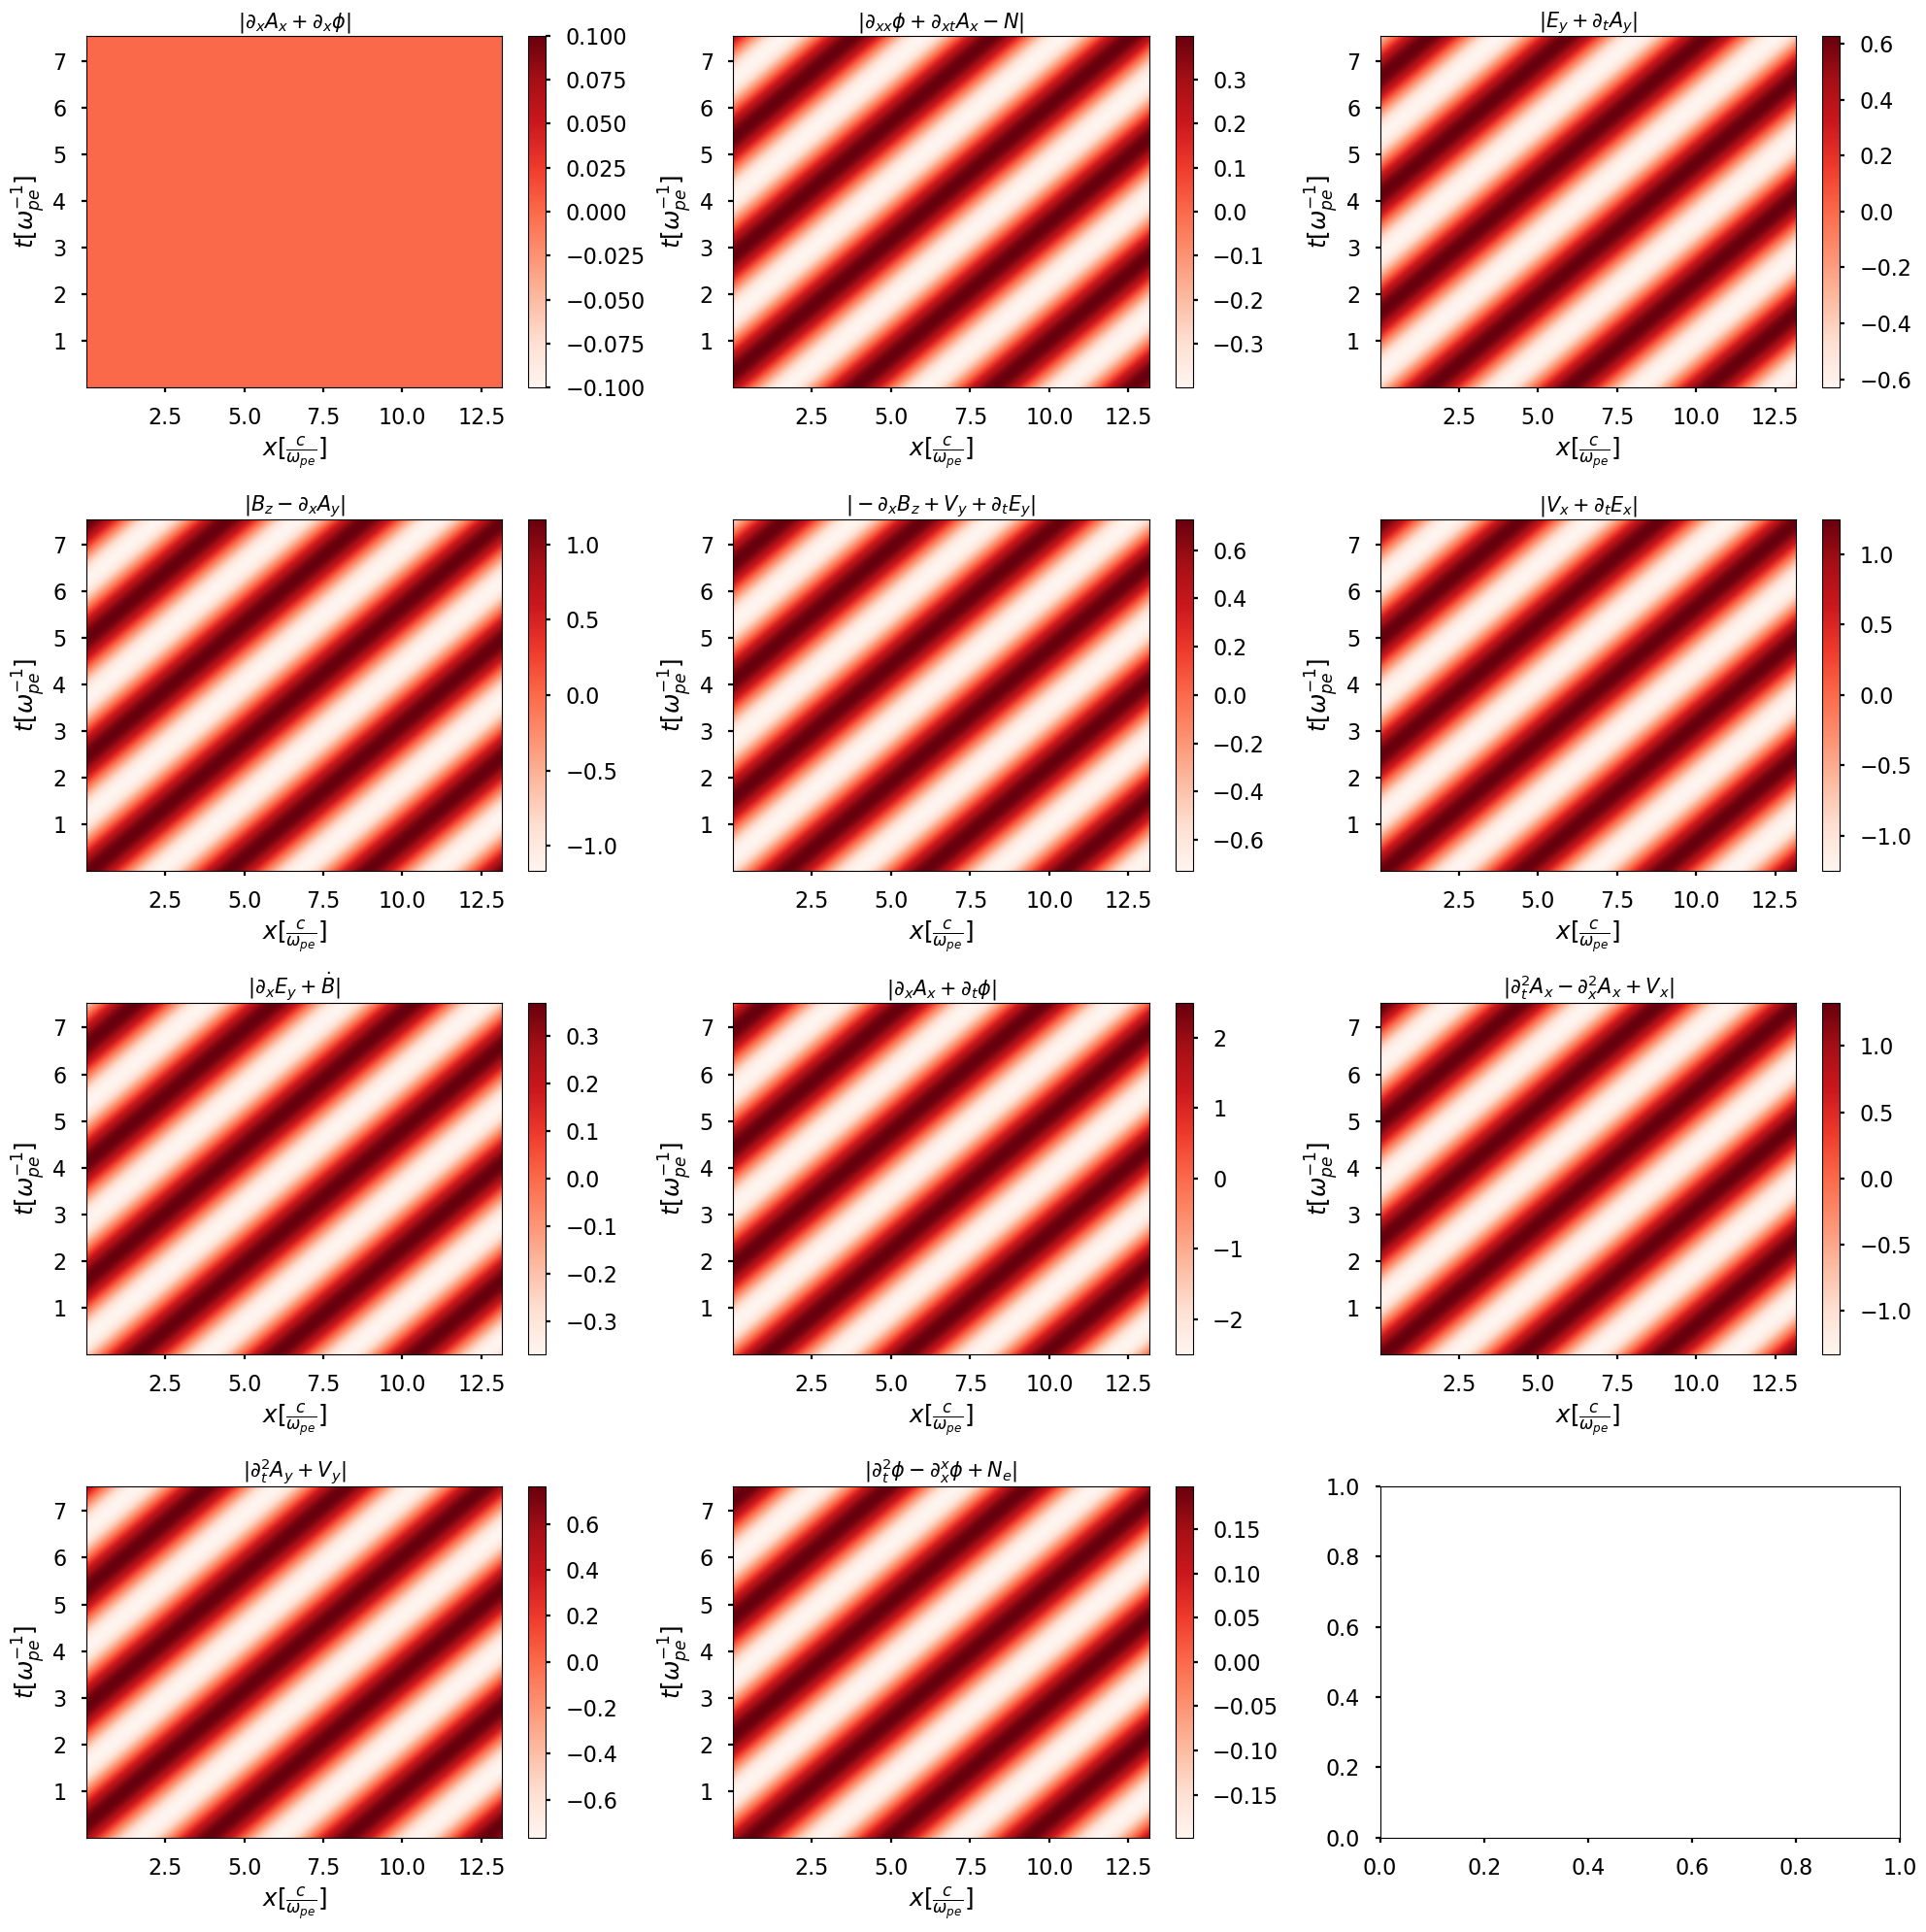

<Figure size 1280x880 with 0 Axes>

In [5]:
#Plot constraints
phi = quantities_GT[0]
Bdot= quantities_GT[1]
Ax = quantities_GT[2]
Ay = quantities_GT[3]
Vx = quantities_GT[4]
Vy = quantities_GT[5]
N = quantities_GT[6]


phi_x = derivative_x(phi, dx)
phi_xx = derivative_x(phi_x, dx)
phi_t = derivative_t(phi, dt)
phi_tt = derivative_t(phi_t, dt)
phi_xt = derivative_t(phi_x, dt)

Ax_x = derivative_x(Ax, dx)
Ax_xx = derivative_x(Ax_x, dx)
Ax_t = derivative_t(Ax, dt)
Ax_tt = derivative_t(Ax_t, dt)
Ax_xt = derivative_t(Ax_x, dx)
Ay_x = derivative_x(Ay, dx)
Ay_xx = derivative_x(Ay_x, dx)
Ay_t = derivative_t(Ay, dt)
Ay_tt = derivative_t(Ay_t, dt)
Ay_xt = derivative_t(Ay_x, dt)

Vx_x = derivative_x(Vx, dx)
Vx_t = derivative_t(Vx, dt)
Vy_x = derivative_x(Vy, dx)
Vy_t = derivative_t(Vy, dt)

N_t = derivative_t(N, dt)


B0_amp = 1.
gauge = Ax_x + phi_x             #Gauge
maxwell_1x = phi_xx + Ax_xt - N       #Maxwell_1x
maxwell_2x = Ax_tt - phi_xt + Vx      #Maxwell_2x
maxwell_2y = -Ay_xx + Ay_tt + Vy      #Maxwell_2y
wave_Ax = Ax_xx - Ax_tt + Vx       #Wave_Ax
wave_Ay = Ay_xx - Ay_tt + Vy       #Wave_Ay  
wave_phi = phi_xx - phi_tt + N      #Wave_phi 
bdot_curlA = Bdot - Ay_xt             #B_curl(A)
momentum_x = Vx_t - (phi_x + Ax_t) + Vy*B0_amp #Momentum_x        
momentum_y = Vy_t - Ay_t - Vx*B0_amp      #Momentum_y
continuity = N_t + Vx_x  

constraints_ext = [x_arr[1], x_arr[-2], t_arr[1], t_arr[-2]]
constraints = [gauge, maxwell_1x, maxwell_2x, maxwell_2y,
               wave_Ax, wave_Ay, wave_phi, bdot_curlA,
               momentum_x, momentum_y, continuity]
constraint_titles = [r'$|\partial_x A_x + \partial_x \phi|$', 
          r'$|\partial_{xx} \phi + \partial_{xt} A_x - N|$',
          r'$|E_y + \partial_t A_y|$',
          r'$|B_z - \partial_x A_y|$',
          r'$|-\partial_x B_z + V_y + \partial_t E_y|$',
          r'$|V_x + \partial_t E_x|$',
          r"$|\partial_x E_y + \dot{B}|$",
          r'$|\partial_x A_x + \partial_t \phi|$',
          r'$|\partial_{t}^{2} A_x - \partial_{x}^{2} A_x + V_x|$',
          r'$|\partial_{t}^{2} A_y + V_y|$',
          r'$|\partial_{t}^{2} \phi - \partial_{x}^{x} \phi + N_e|$',
          r'$|\partial_t B - \dot{B}|']
plot_constraints(constraints=constraints, titles=constraint_titles, extent = constraints_ext)